# Human in the loop (HITL) for Agentic systems
---

Agentic systems are revolutionizing how businesses automate complex workflows and decision-making processes. Building systems that are deterministic and reliable, while automating user tasks is essential, but at the end of the day, these systems are built on models that are non-deterministic.

Building intelligent autonomous agents that effectively handle user queries requires careful planning and robust safeguards. Although FMs continue to improve, they can still produce incorrect outputs, and because agents are complex systems, errors can occur at multiple stages. For example, an agent might select the wrong tool or use correct tools with incorrect parameters. This might lead to the agent causing latency and cost to your application.

In sensitive scenarios, **human-in-the-loop** (`HITL`) interaction is essential for successful AI agent deployments, encompassing multiple critical touchpoints between humans and automated systems. `HITL` can take many forms, from end-users approving actions and providing feedback, to subject matter experts reviewing responses offline and agents working alongside customer service representatives. The common thread is maintaining human oversight and using human intelligence to improve agent performance. This human involvement helps establish ground truth, validates agent responses before they go live, and enables continuous learning through feedback loops.

## How `HITL` works in LangGraph?
---

LangGraph supports a robust human in the loop mechanism in agent workflows. This means that the framework enables humans or experts to intervene at any point in an automated process. 

### Key capabilities

1. ***Persistent execution state***: `LangGraph` checkpoints the graph state after each step, allowing execution to pause indefinitely at defined nodes. This supports  asynchronous human review or input without time constraints.

2. ***Flexible integration points***: `HITL` logic can be introduced at any point in the workflow. This allows targeted human involvement, such as approving API calls, correcting outputs, or guiding conversations.

### Typical use cases

1. ***🛠️ Reviewing tool calls***: Humans can review, edit, or approve tool calls requested by the LLM before tool execution.
2. ***✅ Validating LLM outputs***: Humans can review, edit, or approve content generated by the LLM.
3. ***💡 Providing context***: Enable the LLM to explicitly request human input for clarification or additional details or to support multi-turn conversations.

### Use case
---

Let's build a product agent that can list some of the high priority tasks and also update the tasks. We will be using a human in the loop to check for the priority, review it, and review the task creation/updating process. We will do these using three ways: 

1. By `interrupting` the entire graph execution, 

2. We will use the `command` primitive to resume the execution with a value provided by the human and

3. We will build a custom router that will integrate a human in the loop implementation in a highly flexible and customized manner.

These three ways can be used in a hierarchical manner depending on the level of control you want the human to have or developers to have on the agentic system.

In [1]:
# First, build the simple agent that has access to local tools
import logging

# first, lets import the necessary libraries required to build the agent in this notebook
from typing import TypedDict, Annotated, List, Optional, Dict, Any
from langgraph.graph import StateGraph, END, START, MessagesState
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display
from pydantic import BaseModel

In [2]:
# set a logger
logging.basicConfig(format='[%(asctime)s] p%(process)s {%(filename)s:%(lineno)d} %(levelname)s - %(message)s', level=logging.INFO)
logger = logging.getLogger(__name__)

### Step 1: Define the Agent State

We will first define the agent state that will remain throughout the operation. This is the state of the graph and the state schema serves as the input for all nodes and edges in the graph.

In [3]:
# Next, we will us the task schema in the graph schema.

# This is the schema that will be used and updated dynamically across graph execution
# which includes the task, the summary and the active campaign information
# Define your State schema
class WorkflowState(BaseModel):
    """Schema for the entire workflow state"""
    user_message: str
    tasks: List[Dict[str, Any]] = []
    messages: List[Any] = []
    summary: Optional[str] = None
    num_tasks_completed: Optional[int] = None
    num_tasks_to_do: Optional[int] = None
    num_tasks_in_progress: Optional[int] = None
    num_tasks_critical: Optional[int] = None
    response: Optional[str] = None

In [4]:
import boto3
session = boto3.session.Session()
region = session.region_name
logger.info(f"Running this example in region: {region}")

# Initialize the bedrock client placeholder
bedrock_client = boto3.client("bedrock-runtime")


# represents the global variables used across this notebook
BEDROCK_RUNTIME: str = 'bedrock-runtime'
# Model ID used by the agent
AMAZON_NOVA_LITE_MODEL_ID: str = "us.amazon.nova-lite-v1:0"
PROVIDER_ID : str = 'amazon'
# Inference parameters
TEMPERATURE: float = 0.1
MAX_TOKENS: int = 512

[2025-05-19 20:51:39,534] p19100 {65438041.py:4} INFO - Running this example in region: us-east-1
[2025-05-19 20:51:39,543] p19100 {credentials.py:1352} INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [5]:
import boto3
import logging
# We are importing this to use any model supported on Amazon Bedrock. In this example
# we will be using the Amazon Nova lite model.
from langchain_aws import ChatBedrockConverse
# This helps checkpoint the memory state of the agent for short term/long term memory
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables.config import RunnableConfig
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Create the llm used by the agent
llm = ChatBedrockConverse(
    model=AMAZON_NOVA_LITE_MODEL_ID,
    provider=PROVIDER_ID, 
    temperature=TEMPERATURE, 
    max_tokens=MAX_TOKENS,
    client=bedrock_client,
)
logger.info(f"Initialized the model {llm} that will power our agent.")

[2025-05-19 20:51:40,038] p19100 {2282892260.py:19} INFO - Initialized the model client=<botocore.client.BedrockRuntime object at 0x10b3727b0> model_id='us.amazon.nova-lite-v1:0' max_tokens=512 temperature=0.1 provider='amazon' supports_tool_choice_values=['auto'] that will power our agent.


In [6]:
import os
import json
# represents the location of the synthetic data. Ideally
# this would be an API call from a service like JIRA, but in this case
# the data is a JSON file which is synthetically generated using Claude 3.7 Sonnet on Amazon Bedrock
DATA_DIR: str = "data"
SYNTHETIC_TASKS_FNAME: str = "team_tasks.json"
TASKS_DATA_FPATH: str = os.path.join("..", DATA_DIR, SYNTHETIC_TASKS_FNAME)

In [7]:
logger.info(f"Going to use synthetic data from the following directory -> {TASKS_DATA_FPATH}. (This would ideally be an API call)")

[2025-05-19 20:51:40,510] p19100 {3891557946.py:1} INFO - Going to use synthetic data from the following directory -> ../data/team_tasks.json. (This would ideally be an API call)


In [8]:
from langchain_core.tools import tool

@tool
def list_tasks(status: Optional[str] = None, priority: Optional[str] = None) -> Dict[str, any]:
    """
    List the tasks with an optional filtering by status or priority. This tool is used 
    when the user asks a question about listing the tasks. This tool lists all the tasks and if 
    the user provides some filtering criteria for status or the priority of tasks to be listed, then
    the agent uses that to list some of the tasks.
    
    Args:
        status: Optional filter for task status (to-do, in-progress, completed, at-risk)
        priority: Optional filter for task priority (low, medium, high)
    
    Returns:
        Dictionary with filtered tasks
    """
    with open(TASKS_DATA_FPATH, 'r') as f:
        data = json.load(f)
    filtered_tasks = data['tasks']
    # Filter by status if needed
    if status:
        filtered_tasks = [task for task in filtered_tasks if task['status'] == status]
    # Filter by priority if needed
    if priority:
        filtered_tasks = [task for task in filtered_tasks if task['priority'] == priority]
    return {"tasks": filtered_tasks}

In [9]:
@tool
def update_task_status(task_id: str, new_status: str) -> Dict[str, Any]:
    """
    Update the status of a task.
    
    Args:
        task_id: The unique identifier of the task
        new_status: The new status to set (to-do, in-progress, completed, at-risk)
    
    Returns:
        Dictionary with updated task or error message
    """
    valid_statuses = ["to-do", "in-progress", "completed", "at-risk"]
    if new_status not in valid_statuses:
        return {"error": f"Invalid status. Must be one of {valid_statuses}"}
    
    with open(TASKS_DATA_FPATH, 'r') as f:
        data = json.load(f)
    
    for i, task in enumerate(data['tasks']):
        if task['id'] == task_id:
            data['tasks'][i]['status'] = new_status
            
            # Write back to file
            with open(TASKS_DATA_FPATH, 'w') as f:
                json.dump(data, f, indent=2)
            
            return {"task": data['tasks'][i], "message": f"Updated task {task_id} status to {new_status}"}
    
    return {"error": f"Task with ID {task_id} not found"}


In [10]:
# define the tools that the ReAct agent can utilize
tools = [list_tasks, update_task_status]

In [11]:
SYSTEM_PROMPT = """You are Maya, a Project Manager Assistant designed to help manage LangGraph development tasks.
You have access to the team's tasks and can perform various operations to help the team stay organized.

Your goal is to help the user understand the current state of their project, provide relevant information about tasks,
and assist with task management.

Analyze the user's request carefully and choose the appropriate tools to fulfill their needs.
Use a step-by-step approach to complex requests, and always provide a helpful summary of your actions.

You have access to the following tools based on the user question and can invoke them individually or sequentially based on the user
request: list_tasks, update_task_status
"""

In [12]:
# Import the function to create a prebuilt ReAct agent from LangGraph.
from langgraph.prebuilt import create_react_agent

# Create the ReAct agent by binding the language model (llm) with the defined tools.
# This agent can now reason about when to use these tools based on user input.
get_realtime_info_react_llm = create_react_agent(
    llm,
    tools=tools, 
    prompt=SYSTEM_PROMPT
)

### Create graph nodes
---

In this portion of the notebook, we create two nodes, one that uses the task schema to process the user input, updates with the updated state after the user inputs the request.

In [13]:
# Define the first node that processes user input
def process_user_input(state: WorkflowState) -> WorkflowState:
    """
    This function processes the user's message and initializes the state.
    """
    # Load task data to populate the state
    try:
        with open(TASKS_DATA_FPATH, 'r') as f:
            data = json.load(f)
        
        # Return a new state object with all the data
        return WorkflowState(
            user_message=state.user_message,
            tasks=data['tasks'],
            messages=[]
        )
    except Exception as e:
        logger.error(f"Error loading task data: {e}")
        return WorkflowState(
            user_message=state.user_message,
            messages=[]
        )

In [14]:
def process_task_request(state: WorkflowState) -> WorkflowState:
    """
    This function processes the task request through the ReAct agent.
    """
    try:
        # Create the message for the agent
        messages = [
            HumanMessage(content=state.user_message)
        ]
        
        # Add context about the tasks to the message
        task_context = f"\nCurrent Project Status: {state.user_message or 'No summary available'}"
        messages[0].content += task_context
        
        agent_input = {
            "messages": messages
        }
        
        # Invoke the agent
        result = get_realtime_info_react_llm.invoke(agent_input)
        print(f"result debug:{result}")
        
        # Extract the output
        if isinstance(result, dict) and "output" in result:
            response = result["output"]
        else:
            response = str(result)
        
        # Update the conversation history
        updated_messages = [
            *state.messages,
            HumanMessage(content=state.user_message),
            AIMessage(content=response)
        ]
        
        # Create a dictionary from the current state
        state_dict = state.model_dump()
        
        # Update the specific fields we want to change
        state_dict["messages"] = updated_messages
        state_dict["response"] = response
        
        # Return a new state with updated values
        return WorkflowState(**state_dict)
    except Exception as e:
        logger.error(f"Error processing task request: {e}")
        error_message = f"I apologize, but I encountered an error while processing your request: {str(e)}"
        
        # Print the exception for debugging
        import traceback
        traceback.print_exc()
        
        # Create a dictionary from the current state
        state_dict = state.model_dump()
        
        # Update with error information
        state_dict["messages"] = [
            *state.messages,
            HumanMessage(content=state.user_message),
            AIMessage(content=error_message)
        ]
        state_dict["response"] = error_message
        
        # Return updated state with error
        return WorkflowState(**state_dict)

In [15]:
def print_stream(result):
    """
    Pretty prints the raw response from a LangGraph workflow result.
    """
    import json
    from pprint import pprint
    
    print("\n" + "=" * 50 + "\n")
    
    # For dictionary results
    if isinstance(result, dict):
        if "messages" in result:
            # Print each message in a readable format
            for i, message in enumerate(result["messages"]):
                # Get message type
                msg_type = type(message).__name__
                print(f"[Message {i+1}] Type: {msg_type}")
                
                # Print content in readable format
                if hasattr(message, "content"):
                    print("\nContent:")
                    if isinstance(message.content, list):
                        for j, part in enumerate(message.content):
                            print(f"\n-- Part {j+1} --")
                            pprint(part)
                    else:
                        print(message.content)
                    
                print("\n" + "-" * 50 + "\n")
        else:
            # Just pretty print the dictionary
            pprint(result)
    
    # For list results
    elif isinstance(result, list):
        for i, item in enumerate(result):
            print(f"\n[Item {i+1}]\n")
            print_stream(item)  # Recursively handle items
    
    # For other types
    else:
        print(f"Type: {type(result)}")
        print("\nContent:")
        print(result)
        
    print("\n" + "=" * 50 + "\n")

### Design patterns: Human-in-the-loop
---

The `interrupt` function in `LangGraph` enables `human-in-the-loop` workflows by pausing the graph at a specific node, presenting information to a human, and resuming the graph with their input. It's useful for tasks like approvals, edits, or gathering additional context.

There are three main patterns while integrating the human in the loop functionality within your `agentic` application:

1. `Approve or reject`: This is the case when the agentic AI application enables the user to pause the execution of the graph at a step before a sensitive step, such as making an API call, or an action that needs some sort of human review, such as reviewing the tool call, or anything else. In this case, you can pause the graph using `LangGraph`s `interrupt` functionality, and based on the approval from the human, either route the request or end the execution, or ***route the request to a new node***. This pattern often involves routing the request to a new node.

2.`Edit the graph state`: In this case, you can pause the graph execution and update the graph state with more information with input from the human.

3. `Get input`: This is the design pattern when your agent explicitly asks the user for human input at a particular step of the execution. This is useful for collecting additional information or context to inform the agent's decision making process better.

#### 1️⃣ Approve or Reject before calling tools

In [16]:
# lets create a node that will look for approval or rejection of the tool call
from typing import Literal
from langgraph.types import interrupt, Command

# For more information on Command, view here: https://blog.langchain.dev/command-a-new-tool-for-multi-agent-architectures-in-langgraph/
# You can use the Command return type to show the possible nodes that this node can route to based on the
# input from the human.
def human_approve_or_reject_pattern(state: WorkflowState) -> dict:
    # Prompt the user, embedding state.user_message for context
    prompt = (
        f"Do you approve updating the task “{state.user_message}”? (yes/no)"
    )
    print(f"Prompt: {prompt}")
    # Pause here and receive the user’s reply when resuming
    answer = interrupt(prompt)
    print(f"Answer: {answer}")
    # Normalize the reply into a boolean flag
    approved = answer.strip().lower() in ("yes", "y", "true")
    return {"approved": approved}

#### 2️⃣ Review & Edit the project summary

In [24]:
def human_edit_summary(state: WorkflowState) -> dict:
    """
    Ask the user to review or revise the project summary in the context of
    their original message.
    """
    prompt = (
        f"Please review or revise the project summary for your request:\n\n"
        f"  “{state.user_message}”\n\n"
        f"Current summary: {state.summary!r}\n\n"
        "Enter a new summary or press Enter to keep this one."
    )
    revised = interrupt(prompt)
    # if they just hit Enter, leave summary unchanged
    return {"summary": revised if revised.strip() else state.summary}



#### 3️⃣ Get additional input with validation

In [25]:
def human_get_priority(state: WorkflowState) -> dict:
    """
    Ask the user which priority to apply, in the context of their original message.
    """
    base_question = (
        f"What priority would you like to set for:\n\n"
        f"  “{state.user_message}”\n\n"
        "(low / medium / high)"
    )
    question = base_question
    while True:
        answer = interrupt(question)
        answer_clean = answer.strip().lower()
        if answer_clean in {"low", "medium", "high"}:
            return {"requested_priority": answer_clean}
        # if invalid, loop again with an error
        question = (
            f"“{answer}” isn’t valid. Please enter one of: low, medium, or high.\n\n"
            f"Original request: “{state.user_message}”"
        )

In [26]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# 1) First, create the graph and add all nodes
workflow = StateGraph(WorkflowState)
# core nodes
workflow.add_node("process_user_input", process_user_input)
workflow.add_node("human_edit_summary", human_edit_summary)
workflow.add_node("human_approve_or_reject_pattern", human_approve_or_reject_pattern)
workflow.add_node("human_get_priority", human_get_priority)
workflow.add_node("process_task_request", process_task_request)

# wire in the sequence:
workflow.add_edge(START, "process_user_input")
workflow.add_edge("process_user_input", "human_approve_or_reject_pattern")
workflow.add_edge("human_approve_or_reject_pattern", "human_edit_summary")
workflow.add_edge("human_edit_summary", "human_get_priority")
workflow.add_edge("human_get_priority", "process_task_request")
workflow.add_edge("process_task_request", END)

In [27]:
memory = MemorySaver()
app = workflow.compile(
    checkpointer=memory
)

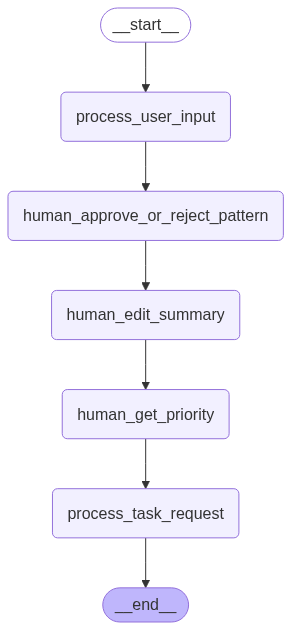

In [28]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [29]:
input_data = {"user_message": "I want to update task TASK-035 to completed."}
config = {"configurable": {"thread_id": "user1"}}

In [30]:
# 1) Catch the interrupt
stream = app.stream(input_data, config=config, stream_mode="updates")
for event in stream:
    print_stream(event)
    if "__interrupt__" in event:
        # unwrap the tuple to get the Interrupt object
        interrupt_obj = event["__interrupt__"][0]
        prompt = interrupt_obj.value
        print("🔔 Approval needed:", prompt)
        break

# 2) Resume from where you left off
reply = input("Your answer (yes/no): ").strip()
for evt in app.stream(
    Command(resume=reply),
    config=config,
    stream_mode="updates"
):
    print_stream(evt)




{'process_user_input': {'messages': [],
                        'tasks': [{'description': 'Create a high-level '
                                                  'architecture design '
                                                  'document for our Maya '
                                                  'project manager agent built '
                                                  'with LangGraph. Include '
                                                  'state management, memory '
                                                  'persistence strategy, tool '
                                                  'integration patterns, and '
                                                  'graph structure.',
                                   'due_date': '2024-09-15',
                                   'id': 'TASK-001',
                                   'name': 'LangGraph Agent Architecture '
                                           'Design',
                              

Prompt: Do you approve updating the task “I want to update task TASK-035 to completed.”? (yes/no)
Answer: yes


{'human_approve_or_reject_pattern': None}




{'__interrupt__': (Interrupt(value='Please review or revise the project '
                                   'summary for your request:\n'
                                   '\n'
                                   '  “I want to update task TASK-035 to '
                                   'completed.”\n'
                                   '\n'
                                   'Current summary: None\n'
                                   '\n'
                                   'Enter a new summary or press Enter to keep '
                                   'this one.',
                             resumable=True,
                             ns=['human_edit_summary:750d9441-6ef2-7e2d-5717-068087dbf839'],
                             when='during'),)}


